# The Air Jordan Resale Market: An Exploratory Data Analysis

**Author:** Darius Follins
**Dataset:** [Jordan Market Dataset 2026](https://www.kaggle.com/datasets/abdullahmeo/air-jordan-sneaker-market-and-resale-data2023-2026/data) (synthetic, 5,000 transactions, 2023–2025) — Kaggle

## Overview

The sneaker resale market has grown into a multi-billion dollar global industry, with Air Jordans at
its cultural and economic center. This notebook explores a synthetic dataset of 5,000 Air Jordan sales
spanning early 2023 through late 2025, covering both global resale platforms (StockX, GOAT, Stadium
Goods) and independent/local retail channels (kick hub 2026, Walk-in Retail).

**Goals of this notebook:**
1. Validate and clean the raw data
2. Explore distributions of price, margin, and inventory time
3. Break down resale value and turnover by model, colorway, condition, and channel
4. Surface market trends over the 2023–2025 window
5. Translate findings into concrete recommendations for someone buying/selling in this market
6. Summarize findings that could feed into a future predictive model

> **Note on scope:** this is the EDA phase of a larger project. A follow-up notebook will build a
> regression model to predict `Resale_Price_USD`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

PALETTE = "flare"


## 1. Loading the Data

In [2]:
df = pd.read_csv("jordan_market_dataset_2026.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 5,000 rows x 10 columns


,Transaction_ID,Sale_Date,Shoe_Model,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD
0,TRX-100001,2024-10-23,Air Jordan 11 Retro,Sail,Used,225,194.67,GOAT,13,-30.33
1,TRX-100002,2023-10-23,Air Jordan 1 High,Mocha,Deadstock (Brand New),185,230.46,StockX,10,45.46
2,TRX-100003,2023-11-13,Air Jordan 4 Retro,Concord,Deadstock (Brand New),212,270.37,kick hub 2026,33,58.37
3,TRX-100004,2024-02-01,Air Jordan 4 Retro,Mocha,Used,223,180.43,Stadium Goods,60,-42.57
4,TRX-100005,2023-05-29,Air Jordan 1 Low,Mocha,Used,137,117.43,kick hub 2026,30,-19.57


### Data Dictionary

| Column | Meaning |
|---|---|
| `Transaction_ID` | Unique ID for each sale |
| `Sale_Date` | Date the sale closed (`YYYY-MM-DD`) |
| `Shoe_Model` | The Air Jordan silhouette (e.g. Air Jordan 1 High) |
| `Colorway` | The color scheme or named collaboration (e.g. Chicago, Mocha) |
| `Condition` | **Deadstock (Brand New)** = never worn, original packaging; **VNDS (Very Near Deadstock)** = worn once or twice, essentially like-new; **Used** = visibly worn |
| `Retail_Price_USD` | Original MSRP at launch |
| `Resale_Price_USD` | Final price the buyer actually paid |
| `Sales_Channel` | Where the sale happened — **StockX** and **GOAT** are large global resale marketplaces; **Stadium Goods** is a global consignment platform; **kick hub 2026** and **Walk-in Retail** are independent/local retail |
| `Days_in_Inventory` | Days the shoe sat with the seller before it sold |
| `Profit_Margin_USD` | `Resale_Price_USD − Retail_Price_USD`, provided directly in the source data |

We'll also derive `Margin_Pct` below (profit margin as a % of retail price), since it's more comparable
across models with different MSRPs than a raw dollar margin.


## 2. Data Cleaning & Validation

Before drawing any conclusions, let's confirm the data is trustworthy: correct types, no duplicates,
no impossible values, and internal consistency between columns.


In [3]:
# --- Data types ---
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])
cat_cols = ["Shoe_Model", "Colorway", "Condition", "Sales_Channel"]
for c in cat_cols:
    df[c] = df[c].astype("category")

print(df.dtypes)


Transaction_ID                  str
Sale_Date            datetime64[us]
Shoe_Model                 category
Colorway                   category
Condition                  category
Retail_Price_USD              int64
Resale_Price_USD            float64
Sales_Channel              category
Days_in_Inventory             int64
Profit_Margin_USD           float64
dtype: object


In [4]:
# --- Missing values & duplicates ---
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate Transaction_IDs:", df["Transaction_ID"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())


Missing values per column:
Transaction_ID       0
Sale_Date            0
Shoe_Model           0
Colorway             0
Condition            0
Retail_Price_USD     0
Resale_Price_USD     0
Sales_Channel        0
Days_in_Inventory    0
Profit_Margin_USD    0
dtype: int64

Duplicate Transaction_IDs: 0
Fully duplicate rows: 0


In [5]:
# --- Internal consistency: does Profit_Margin_USD == Resale - Retail? ---
implied_margin = df["Resale_Price_USD"] - df["Retail_Price_USD"]
mismatch = (implied_margin - df["Profit_Margin_USD"]).abs() > 0.01
print(f"Rows where Profit_Margin_USD doesn't match Resale - Retail: {mismatch.sum()}")


Rows where Profit_Margin_USD doesn't match Resale - Retail: 0


In [6]:
# --- Range / sanity checks ---
checks = pd.DataFrame({
    "min": [df["Retail_Price_USD"].min(), df["Resale_Price_USD"].min(), df["Days_in_Inventory"].min()],
    "max": [df["Retail_Price_USD"].max(), df["Resale_Price_USD"].max(), df["Days_in_Inventory"].max()],
}, index=["Retail_Price_USD", "Resale_Price_USD", "Days_in_Inventory"])
print(checks)
print()
print("Sale date range:", df["Sale_Date"].min().date(), "to", df["Sale_Date"].max().date())
print()
print("Transactions per year:")
print(df["Sale_Date"].dt.year.value_counts().sort_index())


                      min     max
Retail_Price_USD   110.00  230.00
Resale_Price_USD    55.91  804.58
Days_in_Inventory    1.00   60.00

Sale date range: 2023-01-01 to 2025-09-27

Transactions per year:
Sale_Date
2023    1816
2024    1913
2025    1271
Name: count, dtype: int64


**Findings:** the dataset is clean — no missing values, no duplicate transactions, no negative or
impossible prices/durations, and `Profit_Margin_USD` is internally consistent with `Resale_Price_USD -
Retail_Price_USD`. One caveat worth noting: despite the filename, sales only run from **January 2023
through September 2025** — there's no 2026 data, so any "through 2026" framing in the source description
is inaccurate.

We'll also add a couple of derived columns that make later analysis easier:
- `Sale_Year`, `Sale_Quarter` for time-based grouping
- `Margin_Pct` — profit margin as a percentage of retail price (more comparable across models with
  different MSRPs than a raw dollar margin)


In [7]:
df["Sale_Year"] = df["Sale_Date"].dt.year
df["Sale_Quarter"] = df["Sale_Date"].dt.to_period("Q").astype(str)
df["Margin_Pct"] = (df["Profit_Margin_USD"] / df["Retail_Price_USD"]) * 100

df[["Sale_Date", "Sale_Year", "Sale_Quarter", "Retail_Price_USD", "Resale_Price_USD",
    "Profit_Margin_USD", "Margin_Pct"]].head()


,Sale_Date,Sale_Year,Sale_Quarter,Retail_Price_USD,Resale_Price_USD,Profit_Margin_USD,Margin_Pct
0,2024-10-23,2024,2024Q4,225,194.67,-30.33,-13.480000
1,2023-10-23,2023,2023Q4,185,230.46,45.46,24.572973
2,2023-11-13,2023,2023Q4,212,270.37,58.37,27.533019
3,2024-02-01,2024,2024Q1,223,180.43,-42.57,-19.089686
4,2023-05-29,2023,2023Q2,137,117.43,-19.57,-14.284672


## 3. Univariate Exploration

How are the core numeric fields distributed?


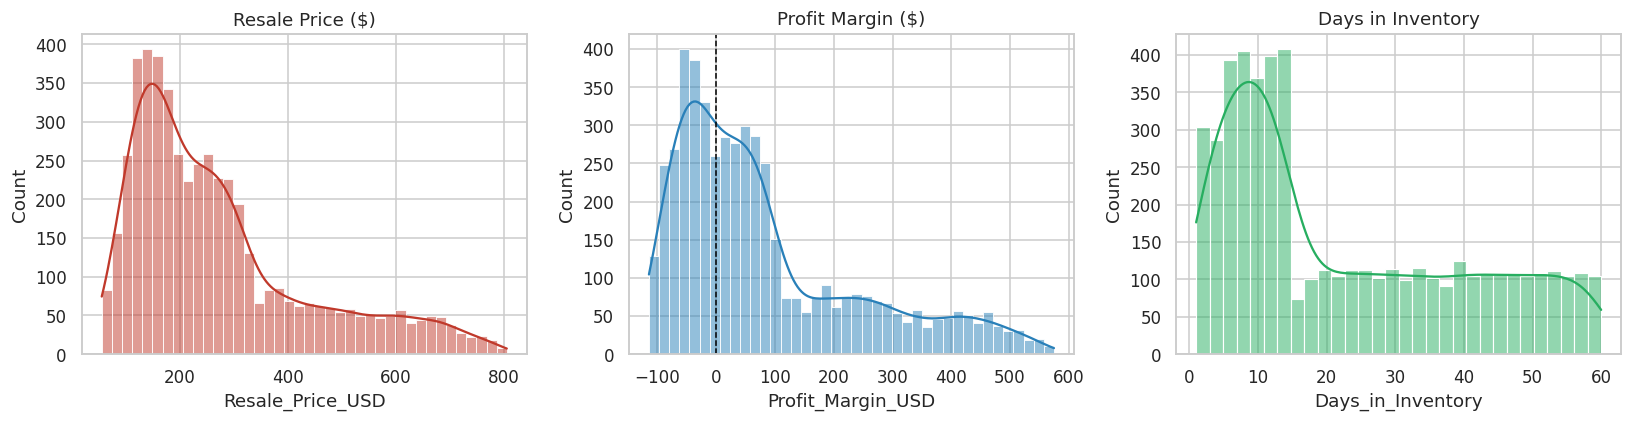

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["Resale_Price_USD"], bins=40, kde=True, ax=axes[0], color="#c0392b")
axes[0].set_title("Resale Price ($)")

sns.histplot(df["Profit_Margin_USD"], bins=40, kde=True, ax=axes[1], color="#2980b9")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Profit Margin ($)")

sns.histplot(df["Days_in_Inventory"], bins=30, kde=True, ax=axes[2], color="#27ae60")
axes[2].set_title("Days in Inventory")

plt.tight_layout()
plt.show()


**Observations:**
- Resale prices are right-skewed — most sales cluster below ~$350, with a long tail of high-value sales
  (rare colorways / low-supply drops) reaching into the $700–800 range.
- Profit margin is **bimodal**: one cluster sits below zero, another sits from roughly $0–$300+. That
  split lines up with `Condition` (Section 4.3 shows Used sales cluster around a loss, while
  Deadstock/VNDS cluster around a profit) rather than being one smooth distribution.
- Days in inventory is also **bimodal** — a fast-moving cluster selling within ~2 weeks and a slower
  cluster taking 25–60 days. This turns out to map closely onto `Sales_Channel` (Section 5): StockX/GOAT
  sales dominate the fast cluster, everything else dominates the slow one.


## 4. Categorical Breakdowns

### 4.1 Resale value & margin by Shoe Model


In [9]:
model_summary = (
    df.groupby("Shoe_Model", observed=True)
      .agg(avg_resale=("Resale_Price_USD", "mean"),
           avg_margin=("Profit_Margin_USD", "mean"),
           avg_margin_pct=("Margin_Pct", "mean"),
           median_days=("Days_in_Inventory", "median"),
           n_sales=("Transaction_ID", "count"))
      .sort_values("avg_margin_pct", ascending=False)
      .round(1)
)
model_summary


,avg_resale,avg_margin,avg_margin_pct,median_days,n_sales
Shoe_Model,,,,,
Air Jordan 1 High,262.2,81.8,45.3,14.0,926
Air Jordan 4 Retro,313.2,95.8,44.0,14.0,1044
Air Jordan 11 Retro,327.3,99.8,43.9,13.0,973
Air Jordan 3 Retro,287.8,82.8,40.4,14.0,1037
Air Jordan 1 Low,175.9,50.5,40.3,16.0,1020


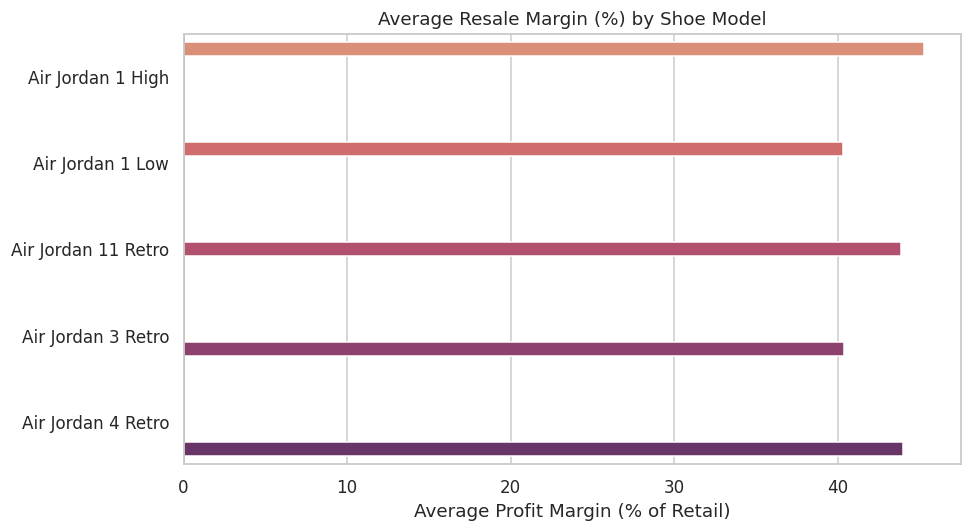

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
order = model_summary.index
sns.barplot(x=model_summary["avg_margin_pct"], y=order, hue=order, palette=PALETTE, ax=ax, legend=False)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Average Profit Margin (% of Retail)")
ax.set_ylabel("")
ax.set_title("Average Resale Margin (%) by Shoe Model")
plt.tight_layout()
plt.show()


**Takeaway:** all five models resell at a profit on average, and the spread between them is
modest — from **Air Jordan 1 High** at the top (+45.3%) down to **Air Jordan 1 Low** and **Air Jordan 3
Retro** at the bottom (+40.3–40.4%). With 900+ sales behind each model average, this ~5-point gap looks
like a real (if small) difference rather than noise, but model alone isn't a dramatic price lever
compared to `Condition` (Section 4.3), which swings margin by 168 points end-to-end.


### 4.2 Resale value by Colorway

Colorway/collab is often the single biggest driver of hype-based resale value — let's see if that
holds here.


In [11]:
colorway_summary = (
    df.groupby("Colorway", observed=True)
      .agg(avg_resale=("Resale_Price_USD", "mean"),
           avg_margin_pct=("Margin_Pct", "mean"),
           n_sales=("Transaction_ID", "count"))
      .sort_values("avg_margin_pct", ascending=False)
      .round(1)
)
colorway_summary


,avg_resale,avg_margin_pct,n_sales
Colorway,,,
Pine Green,278.4,46.4,566
Sail,273.6,45.3,548
Military Blue,279.8,44.7,553
Chicago,276.3,44.6,564
Concord,272.1,42.7,547
Mocha,272.5,42.4,535
Lost & Found,276.9,41.9,585
Bred,267.4,40.8,542
Black Cat,261.6,35.7,560


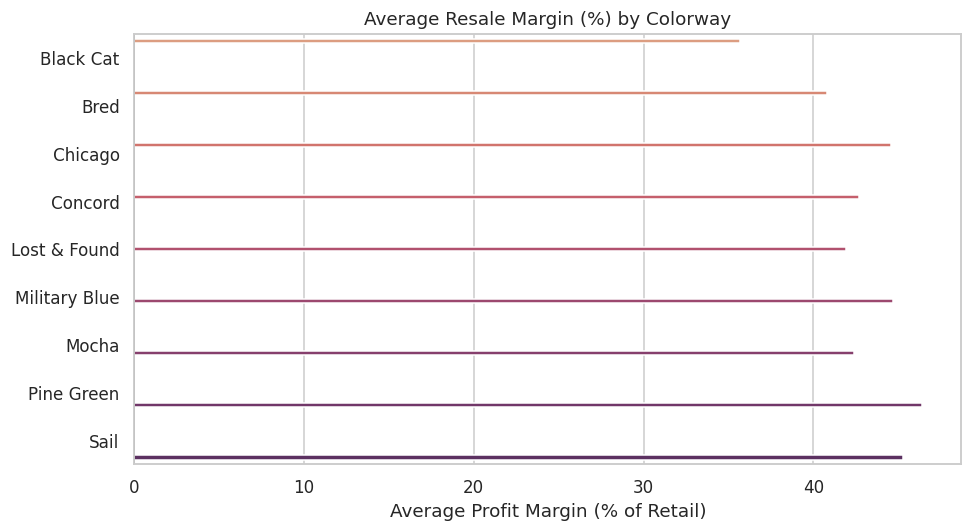

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
order = colorway_summary.sort_values("avg_margin_pct").index
sns.barplot(x=colorway_summary.loc[order, "avg_margin_pct"], y=order, hue=order,
            palette=PALETTE, ax=ax, legend=False)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Average Profit Margin (% of Retail)")
ax.set_ylabel("")
ax.set_title("Average Resale Margin (%) by Colorway")
plt.tight_layout()
plt.show()


**Takeaway:** every single colorway resells at a positive average margin — even the weakest,
**Black Cat** (+35.7%), still nets a profit over retail, it's just the clear outlier at the bottom.
**Pine Green** (+46.4%) and **Sail** (+45.3%) sit at the top. So colorway shifts the *size* of the
profit here, not whether there's a profit at all — a milder effect than the source dataset's
description implied ("colorway drives resale value") might suggest.


### 4.3 Impact of Condition

Does physical condition (Deadstock vs. VNDS vs. Used) actually move the price the way we'd expect?


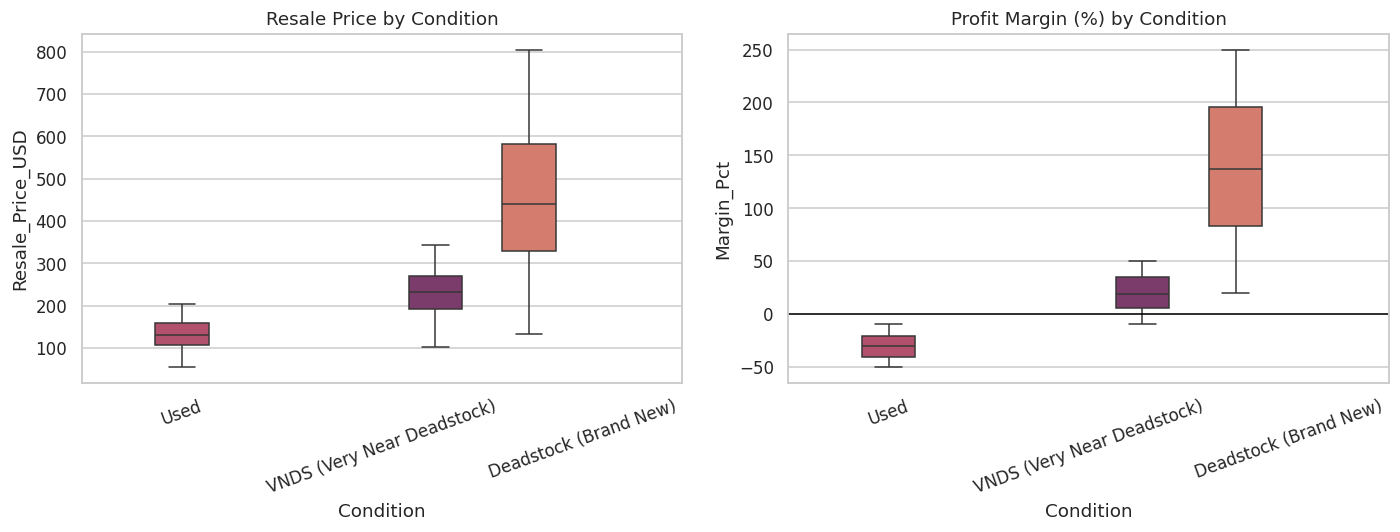

,Resale_Price_USD,Margin_Pct
Condition,,
Deadstock (Brand New),455.5,137.7
Used,132.1,-30.3
VNDS (Very Near Deadstock),229.8,19.6


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ["Used", "VNDS (Very Near Deadstock)", "Deadstock (Brand New)"]
sns.boxplot(data=df, x="Condition", y="Resale_Price_USD", hue="Condition", order=order,
            palette=PALETTE, ax=axes[0], legend=False)
axes[0].set_title("Resale Price by Condition")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="Condition", y="Margin_Pct", hue="Condition", order=order,
            palette=PALETTE, ax=axes[1], legend=False)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Profit Margin (%) by Condition")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

df.groupby("Condition", observed=True)[["Resale_Price_USD", "Margin_Pct"]].mean().round(1)


**Takeaway:** condition behaves exactly as intuition suggests, with a clear ranking: average margin
is **+137.7% for Deadstock (Brand New)**, **+19.6% for VNDS**, and **-30.3% for Used**. Note that VNDS
is also positive on average, not just Deadstock — the real story is that Deadstock is dramatically more
profitable than the other two, and Used is the only condition that sells at a loss on average, spanning
a **168-point swing** from best to worst condition.


## 5. Inventory Optimization: Which Channels Move Shoes Fastest?

### 5.1 Turnover Speed by Channel


In [14]:
channel_summary = (
    df.groupby("Sales_Channel", observed=True)
      .agg(avg_days=("Days_in_Inventory", "mean"),
           median_days=("Days_in_Inventory", "median"),
           avg_resale=("Resale_Price_USD", "mean"),
           avg_margin_pct=("Margin_Pct", "mean"),
           n_sales=("Transaction_ID", "count"))
      .sort_values("median_days")
      .round(1)
)
channel_summary


,avg_days,median_days,avg_resale,avg_margin_pct,n_sales
Sales_Channel,,,,,
GOAT,7.6,8.0,276.5,42.0,1032
StockX,7.5,8.0,265.4,38.0,1027
Stadium Goods,32.8,33.0,272.6,43.6,982
kick hub 2026,32.6,33.0,270.4,43.3,962
Walk-in Retail,33.3,34.0,281.2,46.8,997


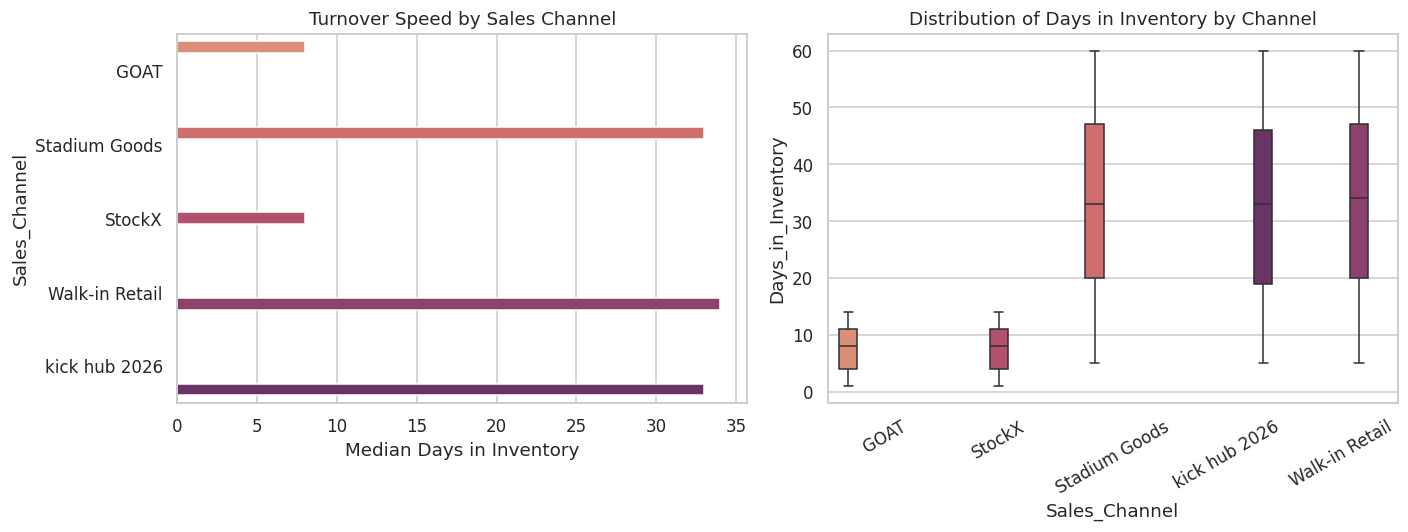

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = channel_summary.index
sns.barplot(x=channel_summary["median_days"], y=order, hue=order, palette=PALETTE,
            ax=axes[0], legend=False)
axes[0].set_xlabel("Median Days in Inventory")
axes[0].set_title("Turnover Speed by Sales Channel")

sns.boxplot(data=df, x="Sales_Channel", y="Days_in_Inventory", hue="Sales_Channel",
            order=order, palette=PALETTE, ax=axes[1], legend=False)
axes[1].set_title("Distribution of Days in Inventory by Channel")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


**Takeaway:** turnover speed splits cleanly into two groups — it's a **binary fast/slow effect, not
a gradient**. StockX and GOAT clear listings in a median of **8 days**, while Stadium Goods, kick hub
2026, and Walk-in Retail all take a median of **33–34 days**. Interestingly, Stadium Goods (a real-world
global platform) behaves like the local/independent channels here rather than like StockX/GOAT — so
"global platform" isn't itself the driver in this dataset; whatever mechanism the data was generated
with, only StockX and GOAT specifically get the fast-turnover treatment. Worth keeping in mind if this
pattern is used as a feature later: it's closer to a 2-category encoding than a continuous "platform
size" effect.


### 5.2 Does Condition Affect Turnover Speed?

Condition is the biggest driver of *price* (Section 4.3) — does it also affect how fast something
sells, or is speed purely a channel story?


In [16]:
condition_speed = (
    df.groupby("Condition", observed=True)["Days_in_Inventory"]
      .agg(["median", "mean"])
      .round(1)
)
condition_speed


,median,mean
Condition,,
Deadstock (Brand New),14.0,23.0
Used,14.0,22.7
VNDS (Very Near Deadstock),14.0,21.7


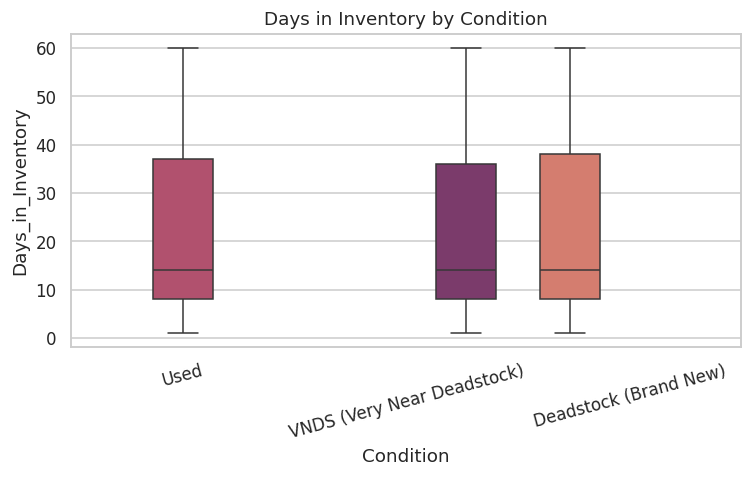

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ["Used", "VNDS (Very Near Deadstock)", "Deadstock (Brand New)"]
sns.boxplot(data=df, x="Condition", y="Days_in_Inventory", hue="Condition", order=order,
            palette=PALETTE, ax=ax, legend=False)
ax.set_title("Days in Inventory by Condition")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


**Takeaway:** condition has essentially **no effect on turnover speed** — the median is exactly
**14 days for all three conditions**, and the means (21.7–23.0) are within a day of each other. This is
a clean, useful finding on its own: in this dataset, `Condition` and `Sales_Channel` do two completely
different jobs — `Condition` decides *how much* a shoe sells for, `Sales_Channel` decides *how fast* it
sells. Neither one influences the other's job.


### 5.3 Channel × Condition: Does the Channel Effect Hold for Every Condition?

Section 5.1 found channel drives speed; Section 5.2 found condition doesn't. Let's confirm that holds
*within* every channel, not just on average — i.e. is a Used pair on StockX still fast, and a Deadstock
pair at Walk-in Retail still slow?


In [18]:
channel_condition_days = df.pivot_table(
    index="Sales_Channel", columns="Condition", values="Days_in_Inventory", aggfunc="median"
).round(1)
channel_condition_days


Condition,Deadstock (Brand New),Used,VNDS (Very Near Deadstock)
Sales_Channel,,,
GOAT,7.0,7.0,8.0
Stadium Goods,34.0,31.5,33.0
StockX,7.0,7.0,8.0
Walk-in Retail,33.0,33.0,34.0
kick hub 2026,31.5,36.0,30.0


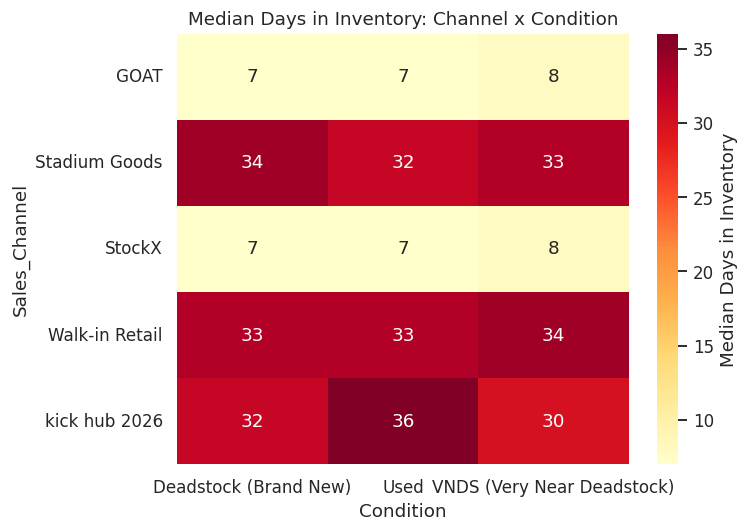

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(channel_condition_days, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Median Days in Inventory"})
ax.set_title("Median Days in Inventory: Channel x Condition")
plt.tight_layout()
plt.show()


**Takeaway:** the pattern holds cleanly across every cell in the grid — StockX and GOAT stay at
7–8 days regardless of condition, and every other channel stays at 30–36 days regardless of condition.
There's no interaction effect here: channel alone determines the speed bucket a sale falls into, and
condition never pulls a sale out of its channel's typical range. For a seller optimizing for fast
turnover, the channel choice matters far more than the condition of the specific pair being listed.


## 6. Market Trends Over Time (2023–2025)

### 6.1 Quarterly Trends


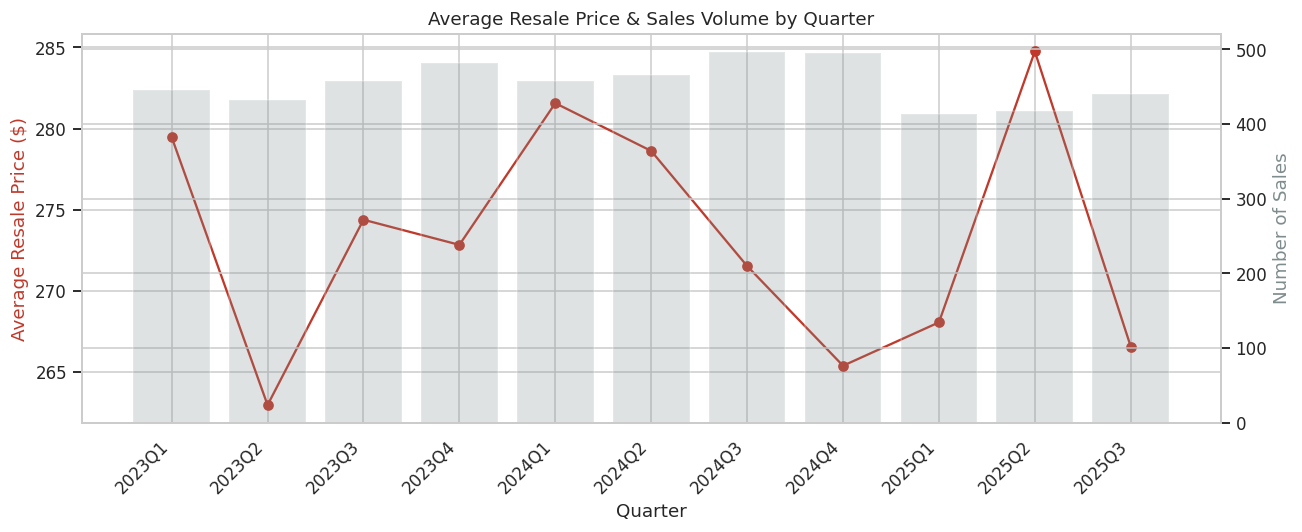

In [20]:
quarterly = (
    df.groupby("Sale_Quarter", observed=True)
      .agg(avg_resale=("Resale_Price_USD", "mean"),
           avg_margin_pct=("Margin_Pct", "mean"),
           n_sales=("Transaction_ID", "count"))
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(quarterly["Sale_Quarter"], quarterly["avg_resale"], marker="o", color="#c0392b", label="Avg Resale Price")
ax2.bar(quarterly["Sale_Quarter"], quarterly["n_sales"], alpha=0.25, color="#7f8c8d", label="Sales Volume")

ax1.set_ylabel("Average Resale Price ($)", color="#c0392b")
ax2.set_ylabel("Number of Sales", color="#7f8c8d")
ax1.set_xlabel("Quarter")
ax1.set_title("Average Resale Price & Sales Volume by Quarter")
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.show()


**Takeaway:** the red line (left axis) is average resale price per quarter; the gray bars (right axis)
are sales volume — the number of transactions that quarter. Both series are essentially flat: average
price stays in a tight $263–$285 band and volume holds around 410–500 sales per quarter, with no clear
upward/downward trend or seasonal pattern across the full 2023–2025 window.


### 6.2 Model Margin Trends (Half-Year, Noise-Controlled)

To see model-level trends without the quarterly noise, we switch to **half-year bins** (which
roughly doubles the sample size per point, ~150–230 sales vs. ~90 per quarter) and plot from the raw
per-transaction data so seaborn can draw a **95% confidence interval** band around each model's line.
Wide, overlapping bands are the tell that a wiggle is noise rather than a real trend.


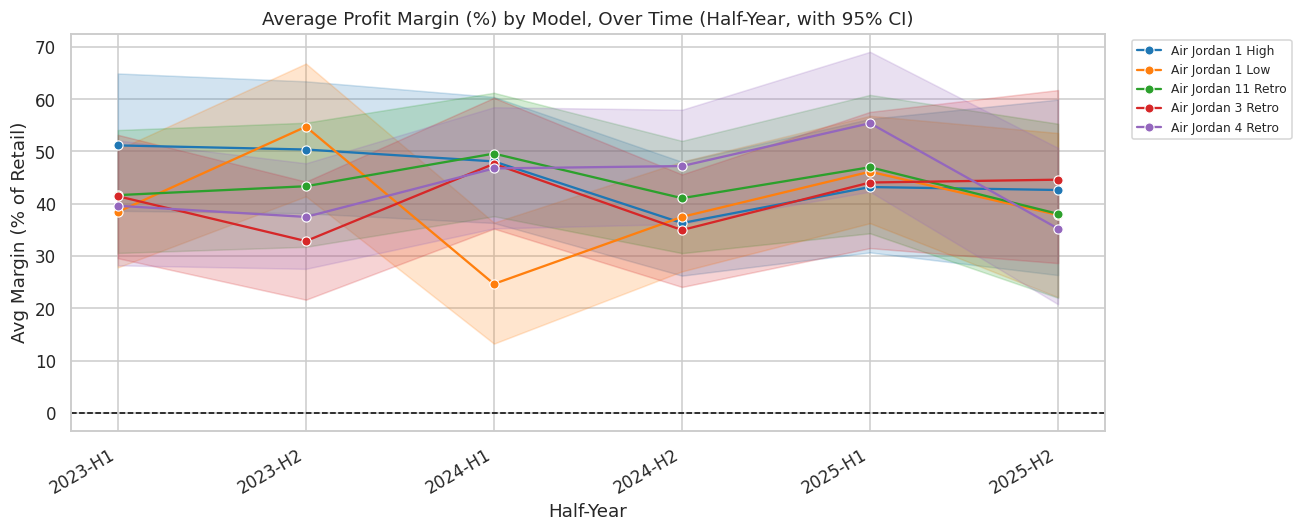

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
df["Sale_Half"] = df["Sale_Date"].dt.year.astype(str) + "-H" + ((df["Sale_Date"].dt.quarter + 1) // 2).astype(str)
half_order = sorted(df["Sale_Half"].unique())
df["Sale_Half"] = pd.Categorical(df["Sale_Half"], categories=half_order, ordered=True)

sns.lineplot(data=df, x="Sale_Half", y="Margin_Pct", hue="Shoe_Model",
             estimator="mean", errorbar=("ci", 95), marker="o", palette="tab10", ax=ax)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Average Profit Margin (%) by Model, Over Time (Half-Year, with 95% CI)")
ax.set_ylabel("Avg Margin (% of Retail)")
ax.set_xlabel("Half-Year")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**Takeaway:** with confidence bands visible, the model lines overlap substantially across most
half-years — the apparent crossovers in the earlier quarterly view were mostly noise, not evidence that
one model's resale value is systematically overtaking another's. Margins for all five models sit in a
broadly similar 35–55% range across the whole period, without a statistically convincing time trend.


### 6.3 Monthly Seasonality: Are There Holiday-Season Price Spikes?

Quarterly and half-year bins could still hide a spike confined to a single month (e.g. a Black
Friday/December surge). We check month-of-year directly, pooling across all three years in the data.


In [22]:
monthly = (
    df.groupby(df["Sale_Date"].dt.month, observed=True)
      .agg(avg_resale=("Resale_Price_USD", "mean"), n_sales=("Transaction_ID", "count"))
      .round(1)
)
monthly.index.name = "Month"
monthly


,avg_resale,n_sales
Month,,
1,273.1,456
2,277.6,427
3,279.3,432
4,271.6,425
5,286.1,476
6,267.0,414
7,276.2,490
8,265.1,468
9,271.2,435


Before charting this, one thing needs flagging: **October, November, and December show noticeably
lower sales counts** (~315–340) than every other month (~410–490). This is *not* a holiday slowdown —
it's a data artifact. The dataset runs through **September 2025**, so Jan–Sep months are built from
**three** years of sales (2023, 2024, 2025) while Oct–Dec months only have **two** (2023, 2024). About
two-thirds of three years' worth of volume is exactly what we'd expect from a flat market, so the lower
counts are explained by missing a partial year, not by an actual seasonal dip. We're calling this out
explicitly so the chart below isn't misread as evidence of a slow fourth quarter.


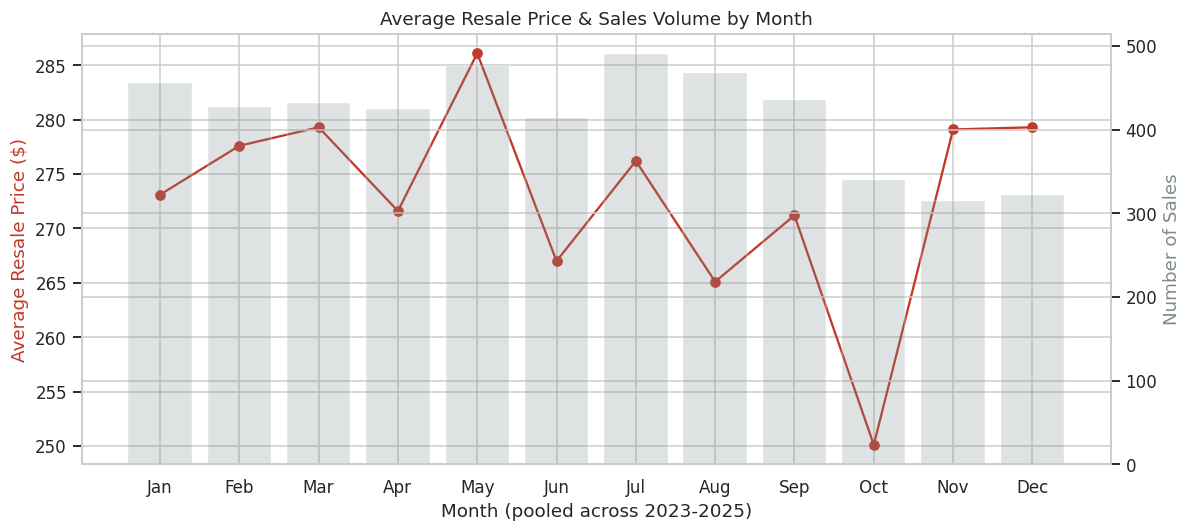

In [23]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax1.plot(month_labels, monthly["avg_resale"], marker="o", color="#c0392b", label="Avg Resale Price")
ax2.bar(month_labels, monthly["n_sales"], alpha=0.25, color="#7f8c8d", label="Sales Volume")

ax1.set_ylabel("Average Resale Price ($)", color="#c0392b")
ax2.set_ylabel("Number of Sales", color="#7f8c8d")
ax1.set_xlabel("Month (pooled across 2023-2025)")
ax1.set_title("Average Resale Price & Sales Volume by Month")
plt.tight_layout()
plt.show()


**Takeaway:** average resale price stays in a $250–$286 range across every month, with October
the single lowest point — but October's *volume* is also lower for the data-coverage reason explained
above, so this looks like ordinary noise from a smaller sample rather than a real seasonal dip. There is
**no visible holiday-season spike** in November or December (both sit right at the yearly average,
~$279). Combined with the flat quarterly and half-year trends, this dataset simply doesn't encode
month-level seasonality — worth knowing before spending modeling effort on month-of-year as a feature.


## 7. Correlations Between Numeric Features


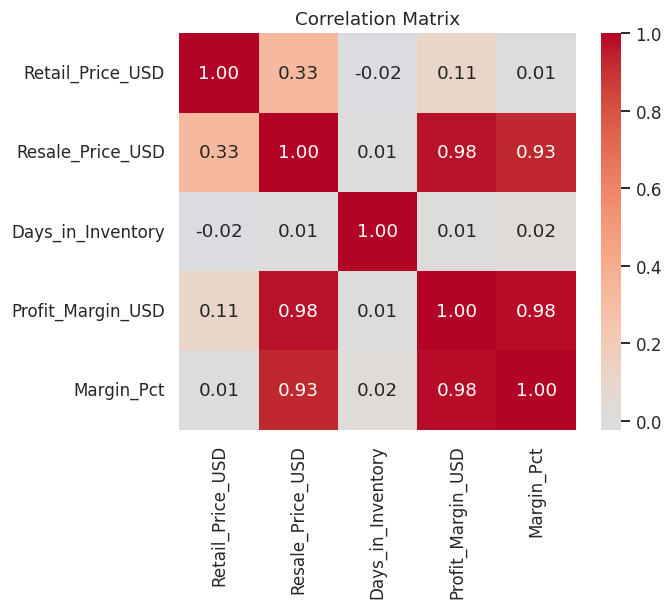

In [24]:
num_cols = ["Retail_Price_USD", "Resale_Price_USD", "Days_in_Inventory", "Profit_Margin_USD", "Margin_Pct"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


**Takeaway:**
- `Days_in_Inventory` correlates near-zero (≤0.02) with every price and margin column — how long a
  shoe sits with the seller tells you essentially nothing about what it eventually sells for. Turnover
  speed (Section 5) is driven by *channel*, not by price or discounting.
- `Retail_Price_USD` and `Resale_Price_USD` are only moderately correlated (0.33) — a higher MSRP does
  not reliably translate into a higher resale price, which fits the earlier finding that `Condition`
  and `Colorway` matter more than the shoe's original price tag.
- `Retail_Price_USD` vs. `Margin_Pct` is essentially zero (0.01) — confirms that expressing margin as a
  *percentage* of retail (rather than raw dollars) successfully removes the effect of MSRP, which is
  exactly why we used `Margin_Pct` for the model/colorway/condition comparisons above.
- `Resale_Price_USD`'s strong correlation with `Profit_Margin_USD`/`Margin_Pct` (0.93–0.98) is expected
  and not a new finding — margin is calculated directly from resale price, so of course they move
  together.


## 8. Recommendations

Translating the findings above into practical advice for someone actually buying/selling in this
market:

- **Sell on StockX or GOAT if speed matters most.** They clear listings in ~8 days median vs. ~30–36
  days everywhere else — a 4x+ difference that swamps every other factor we found for turnover time.
  Stadium Goods does *not* get this benefit here despite being a comparable real-world platform, so
  don't assume "global platform" alone guarantees fast turnover.
- **Prioritize Deadstock condition for margin, not speed.** Condition swings profit margin by **168
  points** (+137.7% for Deadstock vs. -30.3% for Used, Section 4.3) but does nothing for how fast a
  pair sells (Section 5.2) — the two decisions are independent. A seller who needs cash fast should
  pick channel over condition; a seller optimizing for return should do the opposite.
- **Colorway and model are minor tie-breakers, not primary decisions.** Every colorway and model in this
  data resells at a profit, with only a ~5–11 point spread between the best and worst performers
  (Sections 4.1–4.2). Worth factoring in at the margin, but not worth the weight the source dataset's
  framing ("colorway drives resale value") might suggest.
- **Don't bother timing listings around a season or quarter.** There's no evidence of a holiday spike,
  a strong quarter, or a favorable half-year window (Section 6) — in this dataset, *when* you sell
  doesn't matter nearly as much as *where* and *what condition* you sell.


## 9. Summary of Key Findings

- **Data quality:** the dataset is clean — no missing values, duplicates, or invalid ranges. The one
  discrepancy worth flagging is that the data covers Jan 2023–Sept 2025, not through 2026 as the
  filename implies.
- **Condition is a major price driver:** average margin runs **+137.7% for Deadstock**, **+19.6% for
  VNDS**, and **-30.3% for Used** — Deadstock and VNDS both resell at a profit on average, Used
  typically sells at a loss.
- **Colorway and model both shift margin size, not its sign**: every colorway and every model resells
  at a positive average margin — the differences between them (Section 4.1–4.2) are real but modest
  (roughly a 5–11 point spread), a much smaller effect than `Condition`.
- **Sales channel turnover is bimodal, not gradual**: StockX and GOAT clear listings in ~8 days median;
  Stadium Goods, kick hub 2026, and Walk-in Retail all take ~33–34 days. Notably Stadium Goods (a real
  global platform) patterns with the slow group here, not with StockX/GOAT — so channel identity, not
  "global vs. local," is what's driving the split in this data.
- **Condition and channel do independent jobs**: condition drives price (a 168-point margin swing) but
  has no measurable effect on turnover speed (median 14 days regardless of condition), and this holds
  true within every channel individually — there's no interaction between the two.
- **Market trends over 2023–2025 are largely flat at every time resolution we checked** (quarterly,
  half-year, and month-of-year): average resale price hovers in a $250–$286 range with no clear
  upward/downward trend, and there's no visible holiday-season spike in November/December. Note that
  Oct–Dec have lower sales *counts* than other months, but that's a data-coverage artifact (the dataset
  ends in Sept 2025, so those months only have two years of data instead of three), not a seasonal
  effect. Overall, `Sale_Date` is unlikely to be a powerful predictor on its own, though quarter-level
  dummies are still worth testing in the modeling phase.
- **`Days_in_Inventory` is unrelated to price or margin** (correlation ≤0.02 with all price/margin
  columns) — turnover speed is a channel effect, not a pricing effect. It's also not usable as a
  predictor for a future `Resale_Price_USD` model regardless: it's only known *after* a sale completes,
  so using it would be leakage (predicting the past from information that doesn't exist yet at
  listing time).

## Next Steps

This notebook covers cleaning and EDA. The follow-up regression modeling — predicting
`Resale_Price_USD` from `Shoe_Model`, `Colorway`, `Condition`, `Sales_Channel`, and time features,
benchmarking Linear Regression against Random Forest (default and tuned) and Gradient Boosting — lives
in [`jordan_resale_modeling.ipynb`](jordan_resale_modeling.ipynb), which also includes a live
interactive predictor widget. A standalone, no-Python-required version of that same tool — running the
identical tuned Random Forest, exported to JavaScript — is available in
[`jordan_price_predictor.html`](jordan_price_predictor.html).
